# Monitoring Program dan Anggaran SKPD
## Business Understanding
---
*   **Problem:** Government agencies (SKPD) often face challenges in tracking and evaluating program implementation and budget allocation in real time, which may hinder transparency and decision-making.
*   **Objective:** To develop a dashboard that provides a comprehensive overview of SKPD activities, budget distribution, and spending categories, allowing stakeholders to monitor performance and optimize fund usage.
*   **Solution Statement:** The project involved creating a centralized dashboard that integrates data from multiple sources (PostgreSQL, spreadsheets) and presents key performance indicators related to:
    *   Total units and programs
    *   Item counts and total expenditures
    *   Top 5 SKPDs by budget
    *   Spending breakdowns by category, funding source, and expenditure type
    
    The dashboard helps enhance visibility, accountability, and strategic planning within public sector departments.

### What did you learn?
*   Working with government data structure and hierarchies
*   Mapping multiple dimensions (programs, activities, budget) into a meaningful visual format
*   Creating dashboards that are intuitive for public sector use

### What mistakes did you make?
*   Initially underestimated the data cleaning required for public finance records
*   Overlooked the importance of budget categorization consistency across SKPDs

### What would you do differently next time?
*   Collaborate more closely with domain experts to define data hierarchies and metrics
*   Implement automated alerts for budget anomalies in future iterations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['font.family'] = 'sans-serif'

## 1. Data Loading & Overview

In [2]:
# Load the generated dummy dataset
try:
    df = pd.read_csv('data_skpd.csv')
    print("Dataset berhasil dimuat!")
    print(f"Total Baris: {df.shape[0]}")
    print(f"Total Kolom: {df.shape[1]}")
except FileNotFoundError:
    print("File 'data_skpd.csv' tidak ditemukan. Harap jalankan 'generate_dataset.py' terlebih dahulu.")

Dataset berhasil dimuat!
Total Baris: 3727
Total Kolom: 57


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3727 entries, 0 to 3726
Data columns (total 57 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   kode_prov                  3727 non-null   int64  
 1   nama_prov                  3727 non-null   object 
 2   kode_satker                3727 non-null   object 
 3   kode_ddn                   3727 non-null   float64
 4   nama_daerah                3727 non-null   object 
 5   kode_skpd                  3727 non-null   object 
 6   nama_skpd                  3727 non-null   object 
 7   kode_unit_skpd             3727 non-null   object 
 8   nama_unit_skpd             3727 non-null   object 
 9   kode_urusan                3727 non-null   int64  
 10  nama_urusan                3727 non-null   object 
 11  kode_bidang_urusan         3727 non-null   int64  
 12  nama_bidang_urusan         3727 non-null   object 
 13  kode_program               3727 non-null   objec

In [4]:
df.head()

,kode_prov,nama_prov,kode_satker,kode_ddn,nama_daerah,kode_skpd,nama_skpd,kode_unit_skpd,nama_unit_skpd,kode_urusan,...,tahun_anggaran,jenis_apbd,kode_rekening,nama_rekening,kode_sub_rincian_objek,nama_sub_rincian_objek,lokasi,sumber_pendanaan,catatan,status
0,33,Jawa Tengah,SAT-33-029,33.01,Kota Semarang,33.01.15,Dinas Kepemudaan dan Olahraga,33.01.15.03,Bidang Pelaksanaan - Dinas Kepemudaan dan Olah...,2,...,2023,Murni,5.1.01,Rekening Belanja Pegawai,4,E-Purchasing,Puskesmas,APBD Perubahan,Sesuai RPJMD,Proses Verifikasi
1,61,Kalimantan Barat,SAT-61-027,61.01,Kota Pontianak,61.01.10,Dinas Pengendalian Penduduk dan Keluarga Beren...,61.01.10.04,Bidang Evaluasi dan Pelaporan - Dinas Pengenda...,2,...,2022,Murni,1.1.02,Kas di Bendahara Pengeluaran,2,Pengadaan Melalui Tender,Aula Kantor Bupati/Walikota,APBD Murni,Perlu koordinasi lintas SKPD,Disetujui
2,34,DI Yogyakarta,SAT-34-008,34.01,Kota Yogyakarta,34.01.15,Dinas Kepemudaan dan Olahraga,34.01.15.03,Bidang Pelaksanaan - Dinas Kepemudaan dan Olah...,2,...,2022,Murni,5.1.01,Rekening Belanja Pegawai,4,E-Purchasing,Balai Desa,APBD Perubahan,NaN,Disetujui
3,36,Banten,SAT-36-024,36.01,Kota Tangerang,36.01.25,Sekretariat DPRD,36.01.25.04,Bidang Evaluasi dan Pelaporan - Sekretariat DPRD,2,...,2025,Murni,1.1.03,Kas di Bendahara Penerimaan,1,Pembelian Langsung,Balai Desa,Dana Transfer,Sesuai RPJMD,Disetujui
4,33,Jawa Tengah,SAT-33-009,33.01,Kota Semarang,33.01.08,Dinas Kependudukan dan Pencatatan Sipil,33.01.08.04,Bidang Evaluasi dan Pelaporan - Dinas Kependud...,1,...,2023,Murni,1.1.02,Kas di Bendahara Pengeluaran,3,Penunjukan Langsung,Kantor SKPD,APBD Murni,NaN,Disetujui


## 2. Data Cleaning & Preprocessing

In [5]:
# Cek missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if not missing_values.empty:
    print("Missing values ditemukan:")
    print(missing_values)
else:
    print("Tidak ada missing values pada dataset.")

# Memastikan tipe data anggaran berbentuk numerik
df['total_rincian'] = pd.to_numeric(df['total_rincian'], errors='coerce')
df['harga_satuan'] = pd.to_numeric(df['harga_satuan'], errors='coerce')
df['volume'] = pd.to_numeric(df['volume'], errors='coerce')

# Format mata uang untuk display
def format_rupiah(angka):
    return f"Rp {angka:,.0f}".replace(",", ".")

Missing values ditemukan:
catatan    1671
dtype: int64


## 3. Dashboard Analysis & Visualizations

### A. Key Performance Indicators (KPI)

In [6]:
total_unit_skpd = df['nama_unit_skpd'].nunique()
total_program = df['nama_program'].nunique()
total_barang = df['nama_standar_harga'].nunique()
total_anggaran = df['total_rincian'].sum()

print("="*50)
print(f"{'Total Unit SKPD':<20}: {total_unit_skpd:,}")
print(f"{'Total Program':<20}: {total_program:,}")
print(f"{'Total Jenis Barang':<20}: {total_barang:,}")
print(f"{'Total Anggaran Keluar':<20}: {format_rupiah(total_anggaran)}")
print("="*50)

Total Unit SKPD     : 150
Total Program       : 12
Total Jenis Barang  : 50
Total Anggaran Keluar: Rp 9.661.415.474.299


### B. 5 SKPD dengan Anggaran Belanja Tertinggi
Berdasarkan insight, Sekretariat Daerah biasanya mendominasi.

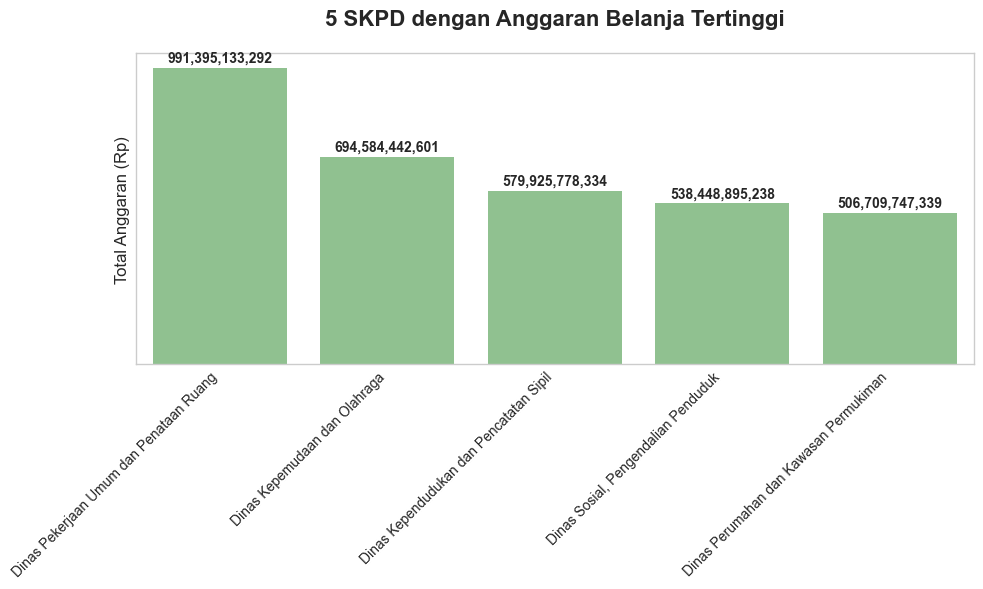

In [7]:
top_skpd = df.groupby('nama_skpd')['total_rincian'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_skpd.index, y=top_skpd.values, color='#88c988') # Light green color similar to reference

plt.title('5 SKPD dengan Anggaran Belanja Tertinggi', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Total Anggaran (Rp)', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks([])

# Add value labels on top of bars
for i, v in enumerate(top_skpd.values):
    ax.text(i, v + (top_skpd.values.max() * 0.02), f"{v:,.0f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### C. Distribusi Anggaran Berdasarkan Sumber Dana

In [8]:
dana_dist = df.groupby('nama_dana')['total_rincian'].sum().sort_values(ascending=False).reset_index()
dana_dist['% Total'] = (dana_dist['total_rincian'] / dana_dist['total_rincian'].sum()) * 100

# Tampilkan sebagai tabel bergaya seperti di referensi
display_df = dana_dist.copy()
display_df['total_rincian'] = display_df['total_rincian'].apply(lambda x: f"{x:,.0f}")
display_df['% Total'] = display_df['% Total'].apply(lambda x: f"{x:.2f}%")
display_df.columns = ['Nama Dana', 'Total Dana', '% Total']
display(display_df.head())

,Nama Dana,Total Dana,% Total
0,Dana Alokasi Umum (DAU),"1,593,731,610,236",16.50%
1,Sisa Lebih Perhitungan Anggaran (SiLPA),"1,247,739,459,720",12.91%
2,Bantuan Keuangan Provinsi,"1,191,688,474,651",12.33%
3,Dana Alokasi Khusus (DAK),"1,177,581,622,924",12.19%
4,Dana Transfer Khusus,"1,136,927,132,725",11.77%


### D. Distribusi Kategori Harga Satuan Barang

Kategori '1 - 1.000': 118 item
Kategori '1.001 - 10.000': 704 item
Kategori '10.001 - 100.000': 1081 item
Kategori 'Di atas 100.000': 1824 item


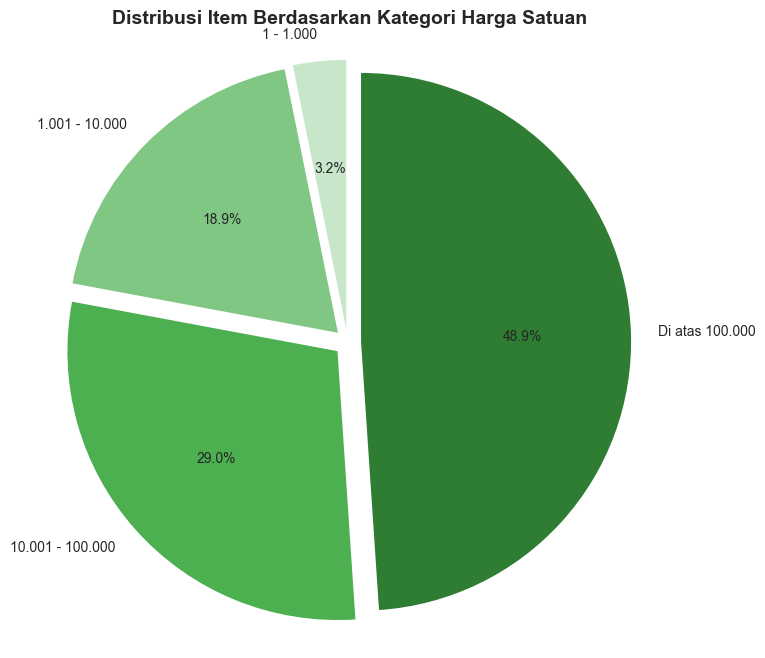

In [9]:
# Membuat kategori harga sesuai insight reference
bins = [0, 1000, 10000, 100000, float('inf')]
labels = ['1 - 1.000', '1.001 - 10.000', '10.001 - 100.000', 'Di atas 100.000']
df['kategori_harga'] = pd.cut(df['harga_satuan'], bins=bins, labels=labels, right=True)

kategori_counts = df['kategori_harga'].value_counts().sort_index()

# Visualisasi Pie Chart
colors = ['#c8e6c9', '#81c784', '#4caf50', '#2e7d32'] # Shades of green
plt.figure(figsize=(8, 8))
plt.pie(kategori_counts, labels=kategori_counts.index, autopct='%1.1f%%', startangle=90, colors=colors,
        explode=(0.05, 0.05, 0.05, 0.05))
plt.title('Distribusi Item Berdasarkan Kategori Harga Satuan', fontsize=14, fontweight='bold')
plt.axis('equal')

# Tambahkan label jumlah absolut
for i, count in enumerate(kategori_counts):
    print(f"Kategori '{kategori_counts.index[i]}': {count} item")

plt.show()

### E. Distribusi Anggaran Berdasarkan Urusan Pemerintahan

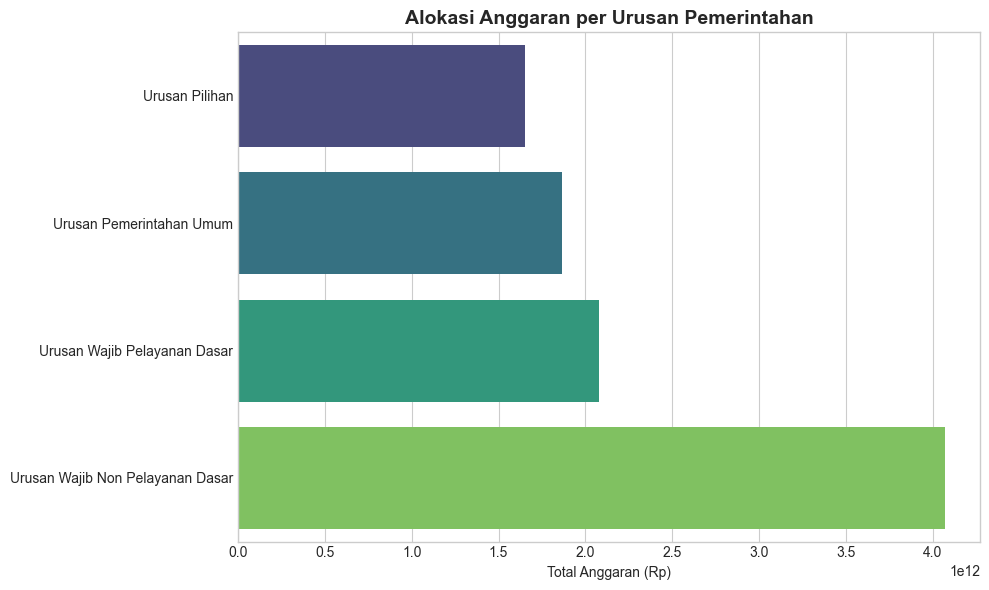

In [10]:
urusan_dist = df.groupby('nama_urusan')['total_rincian'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=urusan_dist.values, y=urusan_dist.index, palette='viridis')

plt.title('Alokasi Anggaran per Urusan Pemerintahan', fontsize=14, fontweight='bold')
plt.xlabel('Total Anggaran (Rp)')
plt.ylabel('')
plt.tight_layout()
plt.show()

### F. Top 5 Program dengan Anggaran Terbesar

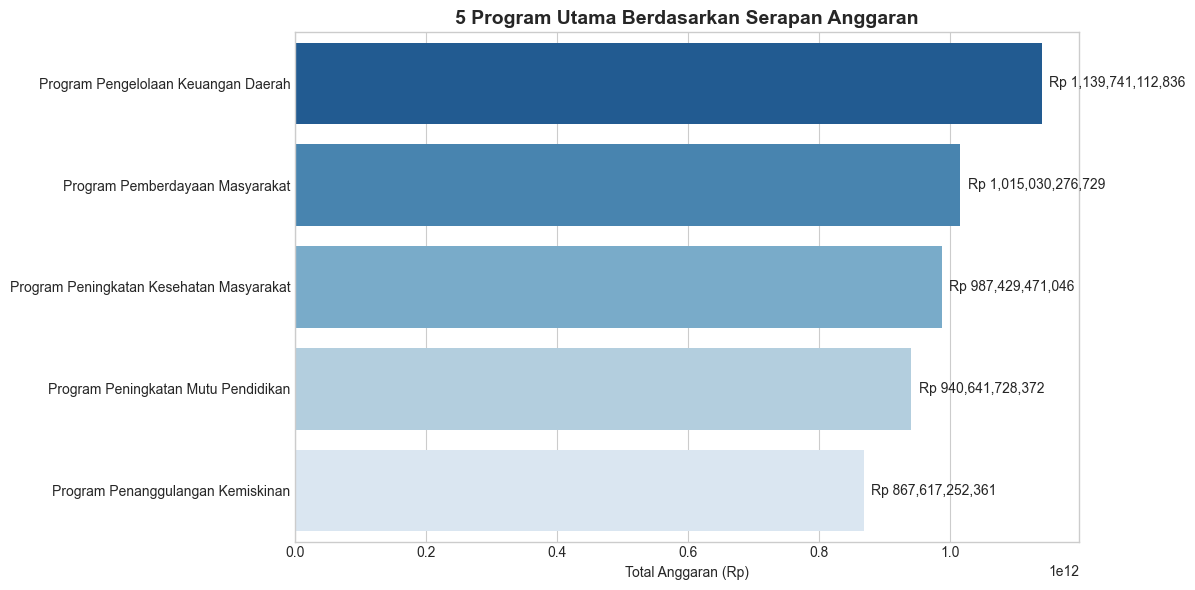

In [11]:
top_program = df.groupby('nama_program')['total_rincian'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_program.values, y=top_program.index, palette='Blues_r')

plt.title('5 Program Utama Berdasarkan Serapan Anggaran', fontsize=14, fontweight='bold')
plt.xlabel('Total Anggaran (Rp)')
plt.ylabel('')

for i, v in enumerate(top_program.values):
    ax.text(v + (top_program.values.max() * 0.01), i, f"Rp {v:,.0f}", va='center')

plt.tight_layout()
plt.show()